Stock Prices Prediction Using Machine Learning and Deep Learning Techniques (with Python codes)

In [4]:
import pandas as pd
from pandas_datareader import data as web
from pandas_datareader.data import DataReader
import plotly.graph_objects as go

In [6]:
#import packages
#import pandas as pd
import numpy as np

#to plot within notebook
import matplotlib.pyplot as plt
%matplotlib inline

#setting figure size
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10

#for normalizing data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
stock = 'AAPL'
 
df = DataReader(stock, data_source='yahoo', start='01-01-2017',end='25-05-2021')



df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-01-03,29.082500,28.690001,28.950001,29.037500,115127600.0,27.413372
2017-01-04,29.127501,28.937500,28.962500,29.004999,84472400.0,27.382690
2017-01-05,29.215000,28.952499,28.980000,29.152500,88774400.0,27.521944
2017-01-06,29.540001,29.117500,29.195000,29.477501,127007600.0,27.828764
2017-01-09,29.857500,29.485001,29.487499,29.747499,134247600.0,28.083660
...,...,...,...,...,...,...
2021-05-18,126.989998,124.779999,126.559998,124.849998,63342900.0,124.849998
2021-05-19,124.919998,122.860001,123.160004,124.690002,92612000.0,124.690002
2021-05-20,127.720001,125.099998,125.230003,127.309998,76857100.0,127.309998


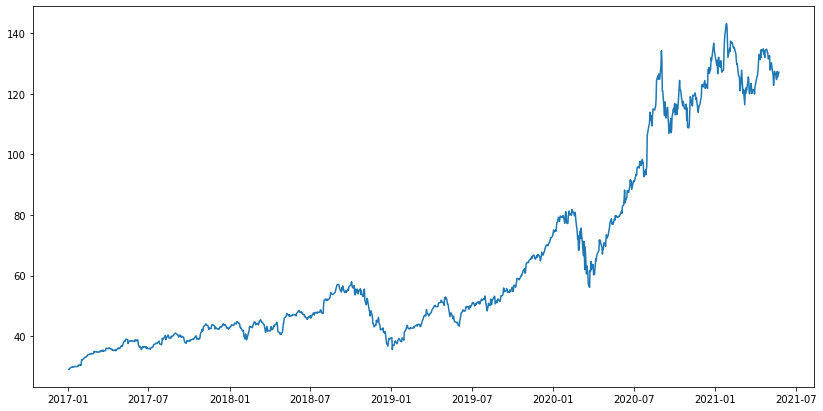

In [8]:
#setting index as date
df['Date']=df.index 
df['Date'] = pd.to_datetime(df.Date,format='%Y-%m-%d')
#df.index = df['Date']

#plot
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Close Price history')

In [10]:
#setting index as date values
#df['Date'] = pd.to_datetime(df.Date,format='%Y-%m-%d')
#df.index = df['Date']

#sorting
data = df.sort_index(ascending=True, axis=0)

#creating a separate dataset
new_data = pd.DataFrame(index=range(0,len(df)),columns=['Date', 'Close'])

for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data['Close'][i] = data['Close'][i]

In [11]:
new_data

,Date,Close
0,2017-01-03 00:00:00,29.0375
1,2017-01-04 00:00:00,29.005
2,2017-01-05 00:00:00,29.1525
3,2017-01-06 00:00:00,29.4775
4,2017-01-09 00:00:00,29.7475
...,...,...
1100,2021-05-18 00:00:00,124.85
1101,2021-05-19 00:00:00,124.69
1102,2021-05-20 00:00:00,127.31
1103,2021-05-21 00:00:00,125.43


In [12]:
#create features
from fastai.tabular import add_datepart
#from fastai.structured import  add_datepart
add_datepart(new_data, 'Date')
new_data.drop('Elapsed', axis=1, inplace=True)  #elapsed will be the time stamp

/usr/local/lib/python3.7/dist-packages/fastai/tabular/transform.py:63: FutureWarning:

Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.



In [13]:
new_data['mon_fri'] = 0
for i in range(0,len(new_data)):
    if (new_data['Dayofweek'][i] == 0 or new_data['Dayofweek'][i] == 4):
        new_data['mon_fri'][i] = 1
    else:
        new_data['mon_fri'][i] = 0

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
#split into train and validation
train = new_data[:987]
valid = new_data[987:]

x_train = train.drop('Close', axis=1)
y_train = train['Close']
x_valid = valid.drop('Close', axis=1)
y_valid = valid['Close']

#implement linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [25]:
y_train

0      29.0375
1       29.005
2      29.1525
3      29.4775
4      29.7475
        ...   
982     116.03
983     116.59
984     119.05
985     122.72
986     123.08
Name: Close, Length: 987, dtype: object

In [26]:
#make predictions and find the rmse
preds = model.predict(x_valid)
rms=np.sqrt(np.mean(np.power((np.array(y_valid)-np.array(preds)),2)))
rms

40.27288649648416

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



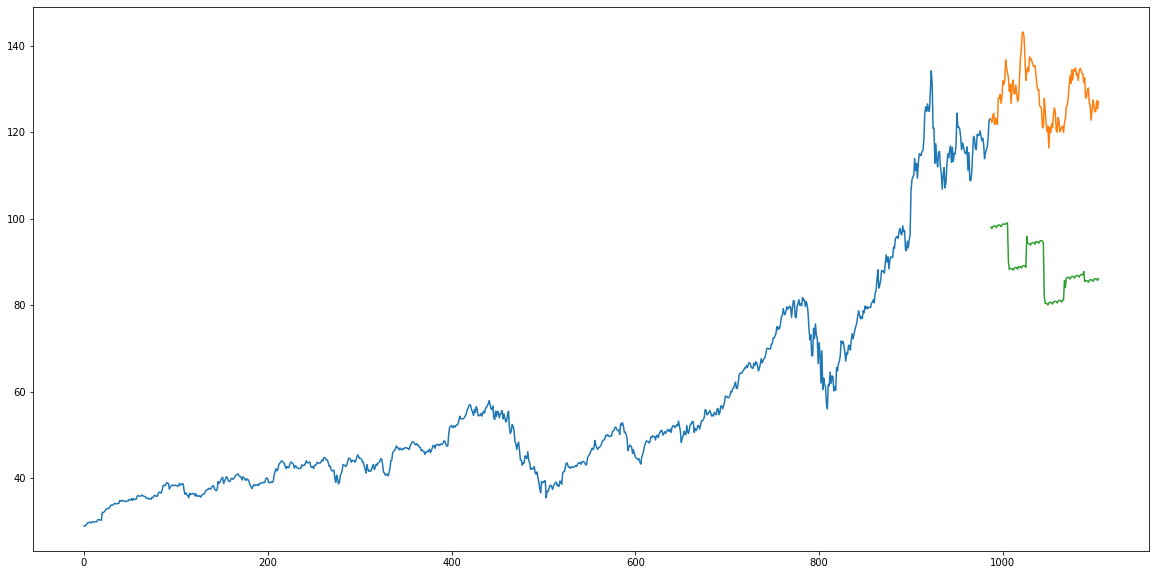

In [17]:
#plot
valid['Predictions'] = 0
valid['Predictions'] = preds

valid.index = new_data[987:].index
train.index = new_data[:987].index

plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])

k-Những người hàng xóm gần nhất
Giới thiệu
Một thuật toán ML thú vị khác mà người ta có thể sử dụng ở đây là kNN (k láng giềng gần nhất). 
Dựa trên các biến độc lập, kNN tìm ra sự giống nhau giữa điểm dữ liệu mới và điểm dữ liệu cũ.

In [27]:
#importing libraries
from sklearn import neighbors
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [28]:
#scaling data
x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)
x_valid_scaled = scaler.fit_transform(x_valid)
x_valid = pd.DataFrame(x_valid_scaled)

#using gridsearch to find the best parameter
params = {'n_neighbors':[2,3,4,5,6,7,8,9]}
knn = neighbors.KNeighborsRegressor()
model = GridSearchCV(knn, params, cv=5)

#fit the model and make predictions
model.fit(x_train,y_train)
preds = model.predict(x_valid)

In [29]:
#rmse
rms=np.sqrt(np.mean(np.power((np.array(y_valid)-np.array(preds)),2)))
rms

62.66351747994949

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



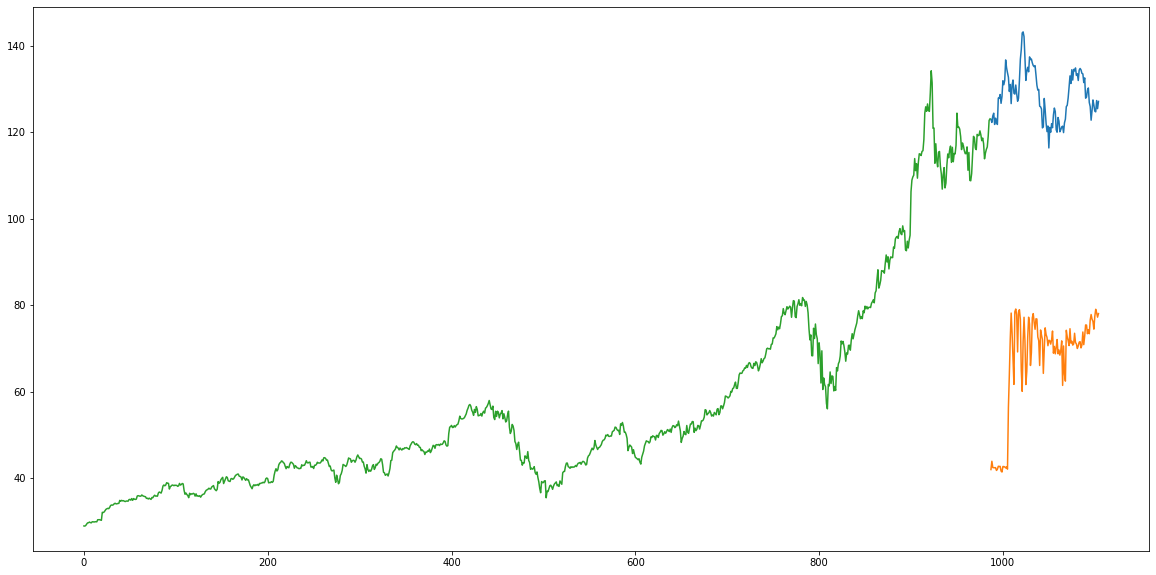

In [30]:
#plot
valid['Predictions'] = 0
valid['Predictions'] = preds
plt.plot(valid[['Close', 'Predictions']])
plt.plot(train['Close'])

ARIMA tự động
Giới thiệu
ARIMA là một phương pháp thống kê rất phổ biến để dự báo chuỗi thời gian.
 Mô hình ARIMA tính đến các giá trị trong quá khứ để dự đoán các giá trị trong tương lai. 
 Có ba thông số quan trọng trong ARIMA:

p (các giá trị trước đây được sử dụng để dự báo giá trị tiếp theo)

q (lỗi dự báo trong quá khứ được sử dụng để dự đoán các giá trị trong tương lai)

d (thứ tự của sự khác biệt)
Việc điều chỉnh tham số cho ARIMA tiêu tốn rất nhiều thời gian. 

Vì vậy, chúng tôi sẽ sử dụng ARIMA tự động tự động chọn kết hợp tốt nhất của (p, q, d) cung cấp ít lỗi nhất.
 Để đọc thêm về cách thức hoạt động của ARIMA tự động, hãy tham khảo bài viết này:
 
 Build High Performance Time Series Models using Auto ARIMA

In [22]:
pip install pmdarima

     |████████████████████████████████| 1.5MB 5.0MB/s 
     |████████████████████████████████| 9.5MB 17.6MB/s 
  Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2


In [31]:
import pmdarima
#import pyramid.arima
from pmdarima.arima import auto_arima

data = df.sort_index(ascending=True, axis=0)

train = data[:987]
valid = data[987:]

training = train['Close']
validation = valid['Close']

model = auto_arima(training, start_p=1, start_q=1,max_p=3, max_q=3, m=12,start_P=0, seasonal=True,d=1, D=1, trace=True,error_action='ignore',suppress_warnings=True)
model.fit(training)

forecast = model.predict(n_periods=118)
forecast = pd.DataFrame(forecast,index = valid.index,columns=['Prediction'])


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=3.65 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4115.505, Time=0.08 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3906.442, Time=0.42 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=2.65 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=4103.102, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=3707.827, Time=1.06 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=6.20 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=3.14 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=3719.334, Time=0.78 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=3708.819, Time=1.44 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=3708.510, Time=1.91 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=3708.672, Time=1.10 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=3710.473, Time=3.94 sec
 ARIMA(1,1,0)(2,1,0)[12] intercept   : AIC=3709.827, Time=4.02 sec

Best model:  ARIMA(1,1,0)(2,1,0)[12]  

In [32]:
rms=np.sqrt(np.mean(np.power((np.array(valid['Close'])-np.array(forecast['Prediction'])),2)))
rms

7.76136243246195

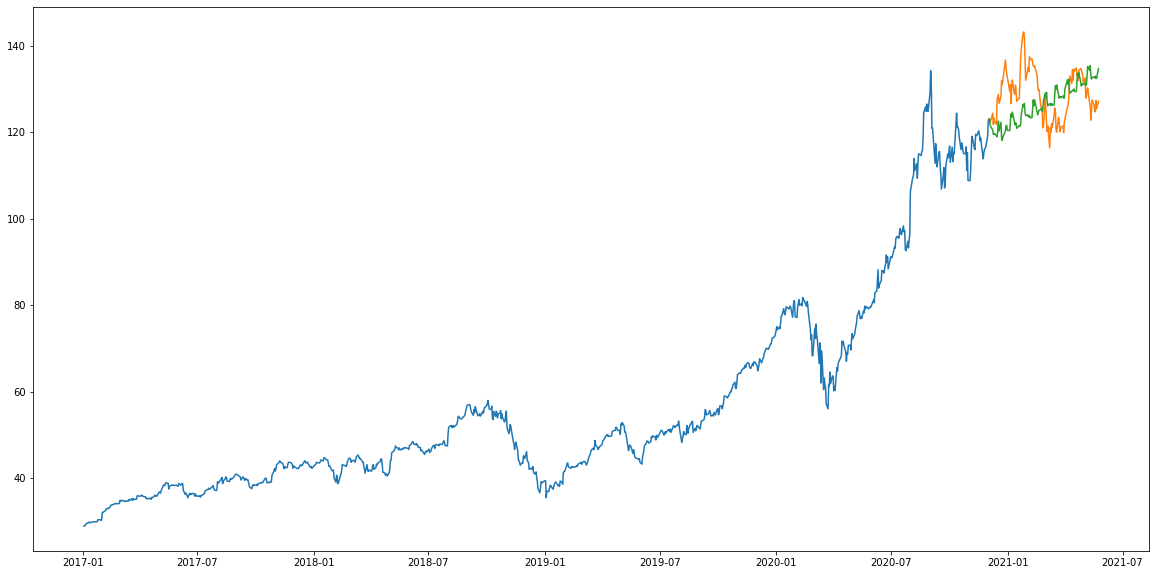

In [33]:
#plot
plt.plot(train['Close'])
plt.plot(valid['Close'])
plt.plot(forecast['Prediction'])

In [34]:
new_data

,Close,Year,Month,Week,Day,Dayofweek,Dayofyear,Is_month_end,Is_month_start,Is_quarter_end,Is_quarter_start,Is_year_end,Is_year_start,mon_fri
0,29.0375,2017,1,1,3,1,3,False,False,False,False,False,False,0
1,29.005,2017,1,1,4,2,4,False,False,False,False,False,False,0
2,29.1525,2017,1,1,5,3,5,False,False,False,False,False,False,0
3,29.4775,2017,1,1,6,4,6,False,False,False,False,False,False,1
4,29.7475,2017,1,2,9,0,9,False,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1100,124.85,2021,5,20,18,1,138,False,False,False,False,False,False,0
1101,124.69,2021,5,20,19,2,139,False,False,False,False,False,False,0
1102,127.31,2021,5,20,20,3,140,False,False,False,False,False,False,0
1103,125.43,2021,5,20,21,4,141,False,False,False,False,False,False,1


Có một số kỹ thuật chuỗi thời gian có thể được thực hiện trên tập dữ liệu dự đoán cổ phiếu, nhưng hầu hết các kỹ thuật này yêu cầu xử lý trước dữ liệu rất nhiều trước khi lắp mô hình. 
Prophet, được thiết kế và tiên phong bởi Facebook, là một thư viện dự báo chuỗi thời gian không yêu cầu xử lý trước dữ liệu và cực kỳ đơn giản để thực hiện. 
Đầu vào cho Prophet là một khung dữ liệu có hai cột: ngày và mục tiêu (ds và y).

Prophet cố gắng nắm bắt tính thời vụ trong dữ liệu quá khứ và hoạt động tốt khi tập dữ liệu lớn.

In [35]:
pip install fbprophet

In [36]:
import pandas as pd
import sklearn as sk
from fbprophet import Prophet

In [37]:
 data = df.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(df)),columns=['Date', 'Close'])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data['Close'][i] = data['Close'][i]

#setting index
new_data.index = new_data.Date
#new_data.drop('Date', axis=1, inplace=True)
 data['Close'][i]

new_data['Date'] = pd.to_datetime(new_data.Date,format='%Y-%m-%d')
new_data.index = new_data['Date']

#preparing data
new_data.rename(columns={'Close': 'y', 'Date': 'ds'}, inplace=True)

#train and validation
train = new_data[:987]
valid = new_data[987:]

#fit the model
model = Prophet()
model.fit(train)

#predictions
close_prices = model.make_future_dataframe(periods=len(valid))
forecast = model.predict(close_prices)

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [38]:
#rmse
forecast_valid = forecast['yhat'][987:]
rms=np.sqrt(np.mean(np.power((np.array(valid['y'])-np.array(forecast_valid)),2)))
rms

7.505547685159512

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



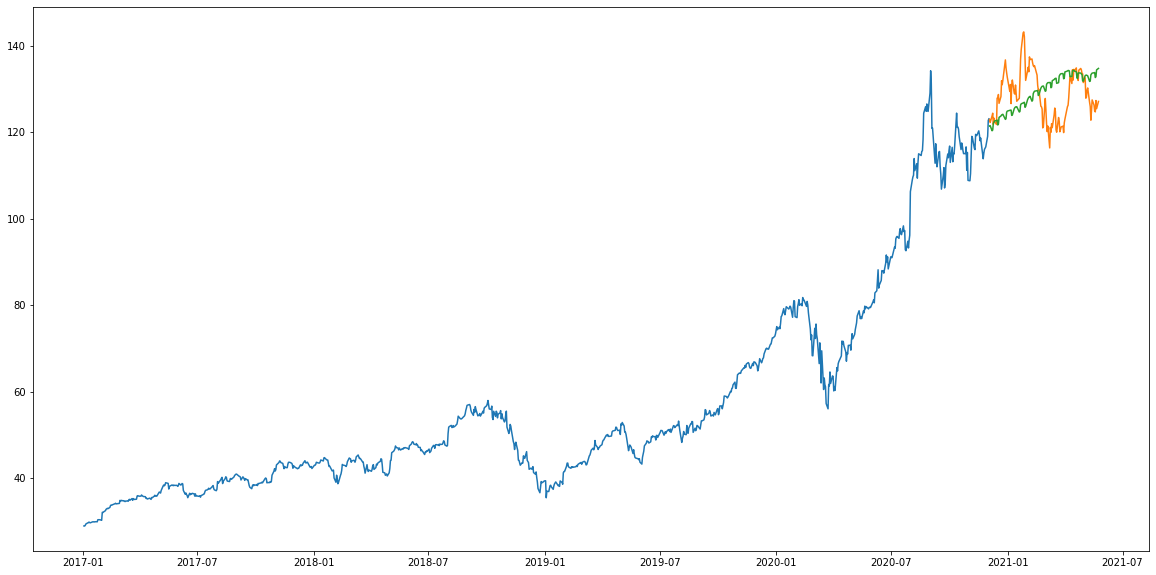

In [39]:
#plot
valid['Predictions'] = 0
valid['Predictions'] = forecast_valid.values

plt.plot(train['y'])
plt.plot(valid[['y', 'Predictions']])

Bộ nhớ ngắn hạn dài hạn (LSTM)
Giới thiệu
LSTM được sử dụng rộng rãi cho các bài toán dự đoán trình tự và đã được chứng minh là cực kỳ hiệu quả. Lý do chúng hoạt động tốt như vậy là vì LSTM có thể lưu trữ thông tin quan trọng trong quá khứ, và quên thông tin không quan trọng. LSTM có ba cổng:

Cổng đầu vào: Cổng đầu vào thêm thông tin vào trạng thái ô

Cổng quên: Nó loại bỏ thông tin không còn được yêu cầu bởi mô hình

Cổng đầu ra: Cổng ra tại LSTM chọn thông tin được hiển thị dưới dạng đầu ra

In [40]:
#importing required libraries
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

#creating dataframe
data = df.sort_index(ascending=True, axis=0)
new_data = pd.DataFrame(index=range(0,len(df)),columns=['Date', 'Close'])
for i in range(0,len(data)):
    new_data['Date'][i] = data['Date'][i]
    new_data['Close'][i] = data['Close'][i]

#setting index
new_data.index = new_data.Date
new_data.drop('Date', axis=1, inplace=True)

#creating train and test sets
dataset = new_data.values

train = dataset[0:987,:]
valid = dataset[987:,:]

#converting dataset into x_train and y_train
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

x_train, y_train = [], []
for i in range(60,len(train)):
    x_train.append(scaled_data[i-60:i,0])
    y_train.append(scaled_data[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(x_train, y_train, epochs=5, batch_size=1, verbose=2)

#predicting 246 values, using past 60 from the train data
inputs = new_data[len(new_data) - len(valid) - 60:].values
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

X_test = []
for i in range(60,inputs.shape[0]):
    X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)

X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
closing_price = model.predict(X_test)
closing_price = scaler.inverse_transform(closing_price)

Epoch 1/5
927/927 - 23s - loss: 0.0018
Epoch 2/5
927/927 - 21s - loss: 9.9398e-04
Epoch 3/5
927/927 - 20s - loss: 6.6266e-04
Epoch 4/5
927/927 - 21s - loss: 6.2451e-04
Epoch 5/5
927/927 - 20s - loss: 4.8018e-04


In [41]:
X_test

array([[[0.773641],
        [0.74009 ],
        [0.727038],
        [0.756471],
        ...,
        [0.767246],
        [0.788796],
        [0.820945],
        [0.824099]],

       [[0.74009 ],
        [0.727038],
        [0.756471],
        [0.758048],
        ...,
        [0.788796],
        [0.820945],
        [0.824099],
        [0.822872]],

       [[0.727038],
        [0.756471],
        [0.758048],
        [0.728177],
        ...,
        [0.820945],
        [0.824099],
        [0.822872],
        [0.816828]],

       [[0.756471],
        [0.758048],
        [0.728177],
        [0.712496],
        ...,
        [0.824099],
        [0.822872],
        [0.816828],
        [0.829968]],

       ...,

       [[0.848452],
        [0.843984],
        [0.80579 ],
        [0.808156],
        ...,
        [0.840655],
        [0.86238 ],
        [0.852043],
        [0.839604]],

       [[0.843984],
        [0.80579 ],
        [0.808156],
        [0.865358],
        ...,
        [0.86238 ],

In [ ]:
rms=np.sqrt(np.mean(np.power((valid-closing_price),2)))
rms

2.7555415660355522

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



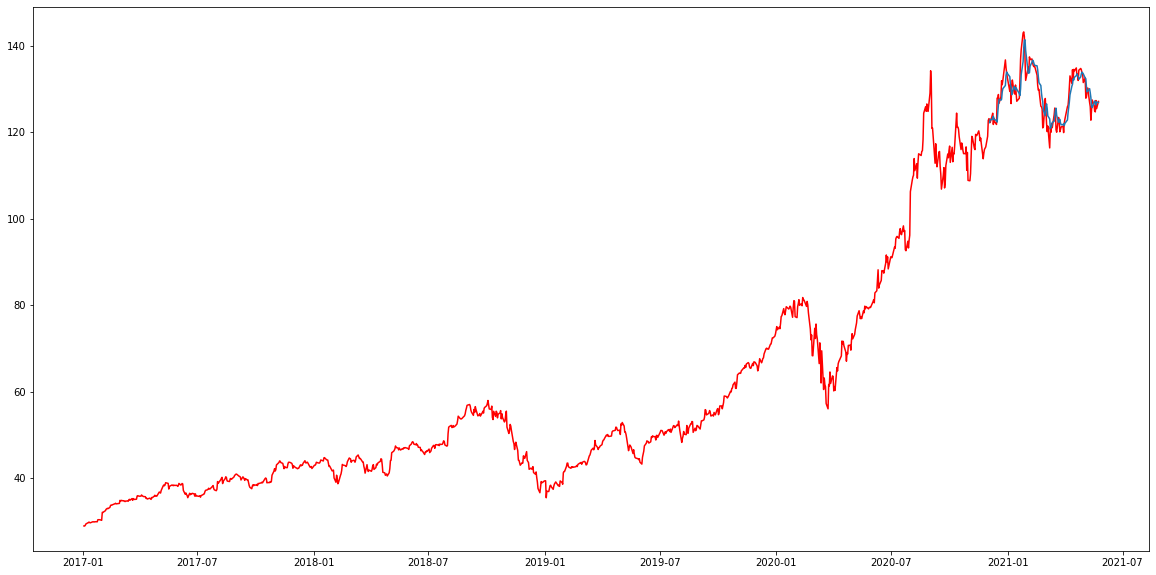

In [ ]:
#for plotting
train = new_data[:987]
valid = new_data[987:]
valid['Predictions'] = closing_price
plt.plot(train['Close'],'red')
plt.plot(valid['Close'],'red')
plt.plot(valid['Predictions'])
#plt.plot(valid[['Close','Predictions']])

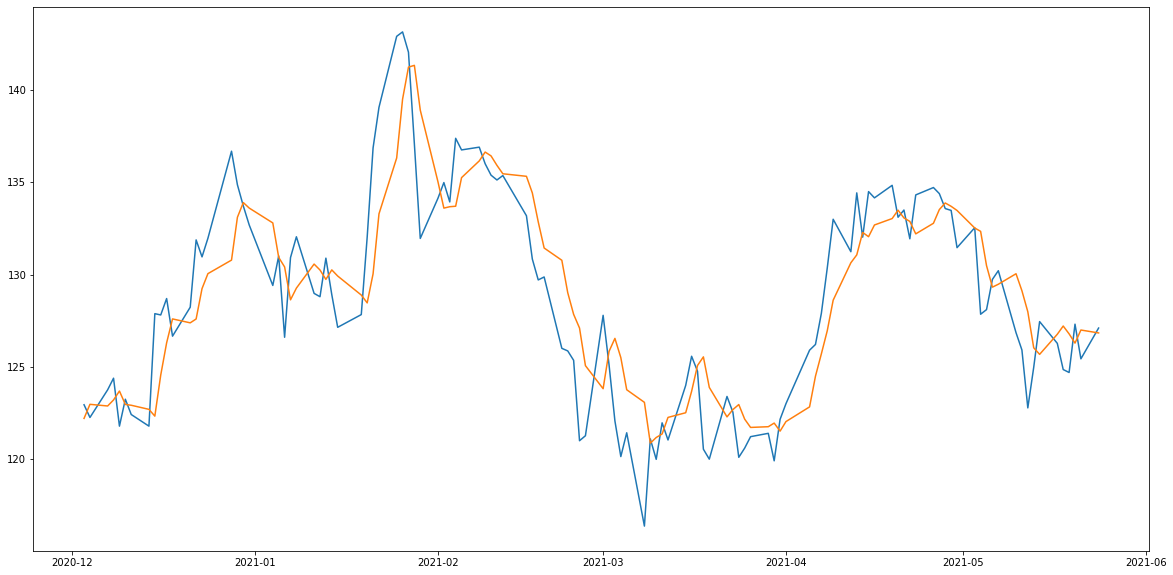

In [ ]:
plt.plot(valid[['Close','Predictions']])